# Xây dựng Dataset — Local Version

Notebook này thực hiện toàn bộ pipeline xử lý dữ liệu **chạy trên máy local (Windows)**,  
không cần Google Colab hay Google Drive.

**Pipeline:**
1. Giải nén 2 bộ dataset gốc từ file ZIP
2. Kiểm tra categories và cấu trúc
3. Map nhãn + Merge thành 1 bộ duy nhất (`dataset_coco_final`)
4. Crop background — loại bỏ vùng nền thừa
5. Chia split 80 / 10 / 10 → `dataset_coco_cropped`
6. Kiểm tra chất lượng và thống kê

**Yêu cầu thư viện:** `pip install pillow tqdm matplotlib`

## Cell 0 — Kiểm tra thư viện

In [1]:
import importlib, subprocess, sys

required = {
    'PIL':        'pillow',
    'tqdm':       'tqdm',
    'matplotlib': 'matplotlib',
}

for mod, pkg in required.items():
    if importlib.util.find_spec(mod) is None:
        print(f'Cai dat {pkg}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

import json, os, shutil, random, zipfile, statistics
from collections import defaultdict, Counter
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

print('Thu vien san sang!')

Cai dat matplotlib...


Thu vien san sang!


## Cell 1 — Cấu hình đường dẫn

In [4]:
# ============================================================
# CAU HINH DUONG DAN — chinh lai neu can
# ============================================================
BASE_DIR    = Path(r'/workspace')

# File ZIP goc (dat trong BASE_DIR)
ZIP_DS1 = BASE_DIR / 'Helmet detection.coco.zip'          # ~4370 anh
ZIP_DS2 = BASE_DIR / 'Helmet Detection Project.coco.zip'  # ~760 anh

# Thu muc giai nen tam
EXTRACT_DIR = BASE_DIR / '_extracted'
DS1_DIR     = EXTRACT_DIR / 'coco1'
DS2_DIR     = EXTRACT_DIR / 'coco2'

# Thu muc dau ra
MERGED_DIR  = BASE_DIR / '_merged'              # sau khi map + merge
CROPPED_DIR = BASE_DIR / 'dataset_coco_cropped' # ket qua cuoi cung

# ============================================================
# THAM SO CROP
# ============================================================
PADDING       = 0.15  # 15% padding xung quanh union bbox
MIN_CROP_SIDE = 64    # crop toi thieu 64px
MIN_BBOX_SIDE = 4     # loai bbox < 4px sau crop

# ============================================================
# MAPPING NHAN
# ============================================================
# Dataset 1: 'Helmet detection.coco.zip'
MAP_DS1 = {
    'with helmet':    'helmet',
    'without helmet': 'no_helmet',
    # cac nhan khac bi bo qua
}
# Dataset 2: 'Helmet Detection Project.coco.zip'
MAP_DS2 = {
    'helmet': 'helmet',
    # cac nhan khac bi bo qua
}

FINAL_CATEGORIES = [
    {'id': 1, 'name': 'helmet'},
    {'id': 2, 'name': 'no_helmet'},
]

# ============================================================
# Kiem tra file ZIP
# ============================================================
print('===== KIEM TRA FILE =====')  
for label, path in [('ZIP DS1', ZIP_DS1), ('ZIP DS2', ZIP_DS2)]:
    size_mb = path.stat().st_size / 1024**2 if path.exists() else 0
    status  = f'OK  ({size_mb:.1f} MB)' if path.exists() else 'KHONG TIM THAY'
    print(f'  {status:25s}  {label}: {path.name}')

print(f'\n  Thu muc dau ra: {CROPPED_DIR}')

===== KIEM TRA FILE =====
  OK  (598.4 MB)             ZIP DS1: Helmet detection.coco.zip
  OK  (869.9 MB)             ZIP DS2: Helmet Detection Project.coco.zip

  Thu muc dau ra: /workspace/dataset_coco_cropped


## Cell 2 — Giải nén 2 dataset

In [5]:
def extract_zip(zip_path: Path, dst: Path, label: str):
    if dst.exists():
        print(f'  Da co (bo qua giai nen): {dst}')
        return
    dst.mkdir(parents=True, exist_ok=True)
    print(f'  Giai nen {label}...', end=' ', flush=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(dst)
    print('xong!')

print('===== GIAI NEN DATASET =====')
extract_zip(ZIP_DS1, DS1_DIR, 'Dataset 1 (Helmet detection)')
extract_zip(ZIP_DS2, DS2_DIR, 'Dataset 2 (Helmet Detection Project)')

# Hien thi cau truc
print()
for label, path in [('Dataset 1', DS1_DIR), ('Dataset 2', DS2_DIR)]:
    print(f'  {label}: {path}')
    for item in sorted(path.iterdir()):
        if item.is_dir():
            n_imgs = len(list(item.glob('*.jpg'))) + len(list(item.glob('*.png')))
            n_json = len(list(item.glob('*.json')))
            print(f'    {item.name}/  ({n_imgs} anh, {n_json} json)')
        else:
            print(f'    {item.name}')

===== GIAI NEN DATASET =====
  Giai nen Dataset 1 (Helmet detection)... xong!
  Giai nen Dataset 2 (Helmet Detection Project)... xong!

  Dataset 1: /workspace/_extracted/coco1
    README.roboflow.txt
    train/  (4352 anh, 1 json)
  Dataset 2: /workspace/_extracted/coco2
    README.roboflow.txt
    train/  (722 anh, 1 json)


## Cell 3 — Kiểm tra categories

In [6]:
def find_annotation(folder: Path):
    """Tim file _annotations.coco.json trong folder."""
    for f in folder.rglob('_annotations.coco.json'):
        return f
    return None

print('===== CATEGORIES TRONG 2 DATASET =====')
for label, ds_dir in [('Dataset 1', DS1_DIR), ('Dataset 2', DS2_DIR)]:
    ann_file = find_annotation(ds_dir)
    if ann_file is None:
        print(f'  {label}: KHONG TIM THAY annotation JSON!')
        continue
    with open(ann_file, encoding='utf-8') as f:
        data = json.load(f)
    cats   = [(c['id'], c['name']) for c in data['categories']]
    n_imgs = len(data['images'])
    n_anns = len(data['annotations'])
    print(f'\n  {label} — {ann_file.relative_to(BASE_DIR)}')
    print(f'    Anh: {n_imgs} | Annotations: {n_anns}')
    print(f'    Categories: {cats}')

print('\n=> Mapping se ap dung:')
print(f'   DS1: {MAP_DS1}')
print(f'   DS2: {MAP_DS2}')

===== CATEGORIES TRONG 2 DATASET =====

  Dataset 1 — _extracted/coco1/train/_annotations.coco.json
    Anh: 4370 | Annotations: 7750
    Categories: [(0, 'helmet-rider-anpr-lEqC'), (1, 'with helmet'), (2, 'without helmet')]

  Dataset 2 — _extracted/coco2/train/_annotations.coco.json
    Anh: 760 | Annotations: 3494
    Categories: [(0, 'helmet-motorbike'), (1, 'helmet'), (2, 'license_plate'), (3, 'motorcyclist')]

=> Mapping se ap dung:
   DS1: {'with helmet': 'helmet', 'without helmet': 'no_helmet'}
   DS2: {'helmet': 'helmet'}


## Cell 4 — Map nhãn + Merge 2 dataset

In [7]:
def process_coco(json_path: Path, img_src_dir: Path, img_dst_dir: Path,
                 class_map: dict, prefix: str,
                 start_img_id: int = 0, start_ann_id: int = 0):
    """
    Doc COCO JSON, map category, copy anh sang thu muc moi.
    Tra ve (new_images, new_annotations, next_img_id, next_ann_id).
    """
    with open(json_path, encoding='utf-8') as f:
        data = json.load(f)

    # Map old category_id -> new category_id
    cat_id_map = {}
    for cat in data['categories']:
        if cat['name'] in class_map:
            new_name = class_map[cat['name']]
            new_id   = 1 if new_name == 'helmet' else 2
            cat_id_map[cat['id']] = new_id

    # Xac dinh anh hop le
    valid_img_ids = set()
    for ann in data['annotations']:
        if ann['category_id'] in cat_id_map:
            valid_img_ids.add(ann['image_id'])

    img_id_map = {}
    new_images, new_annotations = [], []
    new_img_id = start_img_id + 1

    for img in data['images']:
        if img['id'] not in valid_img_ids:
            continue
        old_fname = img['file_name']
        new_fname = prefix + old_fname
        src = img_src_dir / old_fname
        dst = img_dst_dir / new_fname
        if src.exists():
            shutil.copy(src, dst)
        img_id_map[img['id']] = new_img_id
        new_images.append({
            'id':        new_img_id,
            'file_name': new_fname,
            'width':     img.get('width',  640),
            'height':    img.get('height', 640),
        })
        new_img_id += 1

    ann_id = start_ann_id + 1
    for ann in data['annotations']:
        if ann['category_id'] not in cat_id_map:
            continue
        if ann['image_id'] not in img_id_map:
            continue
        bw = float(ann['bbox'][2])
        bh = float(ann['bbox'][3])
        if bw <= 1 or bh <= 1:
            continue
        new_annotations.append({
            'id':          ann_id,
            'image_id':    img_id_map[ann['image_id']],
            'category_id': cat_id_map[ann['category_id']],
            'bbox':        [float(v) for v in ann['bbox']],
            'area':        float(ann.get('area', bw * bh)),
            'iscrowd':     0,
        })
        ann_id += 1

    return new_images, new_annotations, new_img_id, ann_id


# ── Chay merge ──────────────────────────────────────────────
merged_img_dir = MERGED_DIR / 'images'
merged_img_dir.mkdir(parents=True, exist_ok=True)

ann1 = find_annotation(DS1_DIR / 'train') or find_annotation(DS1_DIR)
ann2 = find_annotation(DS2_DIR / 'train') or find_annotation(DS2_DIR)

img_src1 = ann1.parent
img_src2 = ann2.parent

print('Xu ly Dataset 1...')
imgs1, anns1, next_img, next_ann = process_coco(
    ann1, img_src1, merged_img_dir, MAP_DS1, 'ds1_',
    start_img_id=0, start_ann_id=0
)
print(f'  => {len(imgs1)} anh | {len(anns1)} annotations')

print('Xu ly Dataset 2...')
imgs2, anns2, _, _ = process_coco(
    ann2, img_src2, merged_img_dir, MAP_DS2, 'ds2_',
    start_img_id=next_img, start_ann_id=next_ann
)
print(f'  => {len(imgs2)} anh | {len(anns2)} annotations')

merged = {
    'images':      imgs1 + imgs2,
    'annotations': anns1 + anns2,
    'categories':  FINAL_CATEGORIES,
}
merged_ann_file = MERGED_DIR / '_annotations.coco.json'
with open(merged_ann_file, 'w', encoding='utf-8') as f:
    json.dump(merged, f, ensure_ascii=False)

cls_count = Counter()
cat_map   = {c['id']: c['name'] for c in FINAL_CATEGORIES}
for a in merged['annotations']:
    cls_count[cat_map[a['category_id']]] += 1

print(f'\nMerge hoan chinh:')
print(f'  Tong anh        : {len(merged["images"])}')
print(f'  Tong annotations: {len(merged["annotations"])}')
print(f'  Phan bo class   : {dict(cls_count)}')

Xu ly Dataset 1...
  => 4370 anh | 7749 annotations
Xu ly Dataset 2...
  => 545 anh | 855 annotations

Merge hoan chinh:
  Tong anh        : 4915
  Tong annotations: 8604
  Phan bo class   : {'no_helmet': 3750, 'helmet': 4854}


## Cell 5 — Crop Background

Thuật toán: tính **union bbox** của toàn bộ đối tượng trong ảnh,  
mở rộng thêm 15% padding, crop và cập nhật tọa độ annotation.

In [8]:
cropped_img_dir  = MERGED_DIR / '_cropped_images'
cropped_ann_file = MERGED_DIR / '_annotations_cropped.coco.json'
cropped_img_dir.mkdir(parents=True, exist_ok=True)

with open(merged_ann_file, encoding='utf-8') as f:
    src_data = json.load(f)

ann_by_img = defaultdict(list)
for ann in src_data['annotations']:
    ann_by_img[ann['image_id']].append(ann)

new_images, new_annotations = [], []
new_ann_id = 1
stats = {'cropped': 0, 'no_ann': 0, 'no_file': 0,
         'bbox_kept': 0, 'bbox_dropped': 0}

for img_info in tqdm(src_data['images'], desc='Crop anh', unit='img'):
    img_id   = img_info['id']
    fname    = img_info['file_name']
    src_path = merged_img_dir / fname
    dst_path = cropped_img_dir / fname

    anns_img = ann_by_img.get(img_id, [])
    if not anns_img:
        stats['no_ann'] += 1
        continue
    if not src_path.exists():
        stats['no_file'] += 1
        continue

    img_pil = Image.open(src_path).convert('RGB')
    iw, ih  = img_pil.size

    # Tinh union bbox
    x1_all = min(float(a['bbox'][0])                        for a in anns_img)
    y1_all = min(float(a['bbox'][1])                        for a in anns_img)
    x2_all = max(float(a['bbox'][0]) + float(a['bbox'][2]) for a in anns_img)
    y2_all = max(float(a['bbox'][1]) + float(a['bbox'][3]) for a in anns_img)

    # Them padding
    pad_x = (x2_all - x1_all) * PADDING
    pad_y = (y2_all - y1_all) * PADDING
    cx1   = max(0,  x1_all - pad_x)
    cy1   = max(0,  y1_all - pad_y)
    cx2   = min(iw, x2_all + pad_x)
    cy2   = min(ih, y2_all + pad_y)

    # Bao ve: crop toi thieu MIN_CROP_SIDE
    if (cx2 - cx1) < MIN_CROP_SIDE or (cy2 - cy1) < MIN_CROP_SIDE:
        cx1, cy1, cx2, cy2 = 0, 0, iw, ih

    crop_w = cx2 - cx1
    crop_h = cy2 - cy1

    cropped = img_pil.crop((int(cx1), int(cy1), int(cx2), int(cy2)))
    cropped.save(dst_path, quality=95)
    stats['cropped'] += 1

    new_images.append({
        'id': img_id, 'file_name': fname,
        'width': int(crop_w), 'height': int(crop_h),
    })

    for ann in anns_img:
        bx, by, bw, bh = [float(v) for v in ann['bbox']]
        new_bx = bx - cx1
        new_by = by - cy1
        new_x1 = max(0.0,    new_bx)
        new_y1 = max(0.0,    new_by)
        new_x2 = min(crop_w, new_bx + bw)
        new_y2 = min(crop_h, new_by + bh)
        new_bw = new_x2 - new_x1
        new_bh = new_y2 - new_y1
        if new_bw < MIN_BBOX_SIDE or new_bh < MIN_BBOX_SIDE:
            stats['bbox_dropped'] += 1
            continue
        new_annotations.append({
            'id': new_ann_id, 'image_id': img_id,
            'category_id': ann['category_id'],
            'bbox': [round(new_x1,2), round(new_y1,2),
                     round(new_bw,2), round(new_bh,2)],
            'area': round(new_bw * new_bh, 2), 'iscrowd': 0,
        })
        new_ann_id  += 1
        stats['bbox_kept'] += 1

cropped_data = {
    'images':      new_images,
    'annotations': new_annotations,
    'categories':  src_data['categories'],
}
with open(cropped_ann_file, 'w', encoding='utf-8') as f:
    json.dump(cropped_data, f, ensure_ascii=False)

print(f'\nCrop hoan thanh!')
print(f'  Anh da crop      : {stats["cropped"]}')
print(f'  Bo qua (ko ann)  : {stats["no_ann"]}')
print(f'  Bo qua (ko file) : {stats["no_file"]}')
print(f'  BBox giu lai     : {stats["bbox_kept"]}')
print(f'  BBox bo (<{MIN_BBOX_SIDE}px)  : {stats["bbox_dropped"]}')

Crop anh: 100%|██████████| 4915/4915 [00:35<00:00, 136.85img/s]



Crop hoan thanh!
  Anh da crop      : 4915
  Bo qua (ko ann)  : 0
  Bo qua (ko file) : 0
  BBox giu lai     : 8572
  BBox bo (<4px)  : 32


## Cell 6 — Kiểm tra chất lượng crop

So sánh phân bố kích thước bbox trước và sau crop  
(theo không gian pixel sau khi model resize về min=640, max=1024).

Metric                         Truoc crop   Sau crop
Tong bbox                            8604       8572
Median min-edge (px)                 59.0      201.9
Mean min-edge (px)                   77.1      240.7
-------------------------------------------------------
< 16px (sieu nho)                   12.8%       6.4%
< 32px (rat nho)                    25.7%      14.8%
< 64px (nho)                        53.9%      27.3%
>=64px (du lon)                     46.1%      72.7%  <- muc tieu

Cai thien: +26.6 pp cho bbox >= 64px


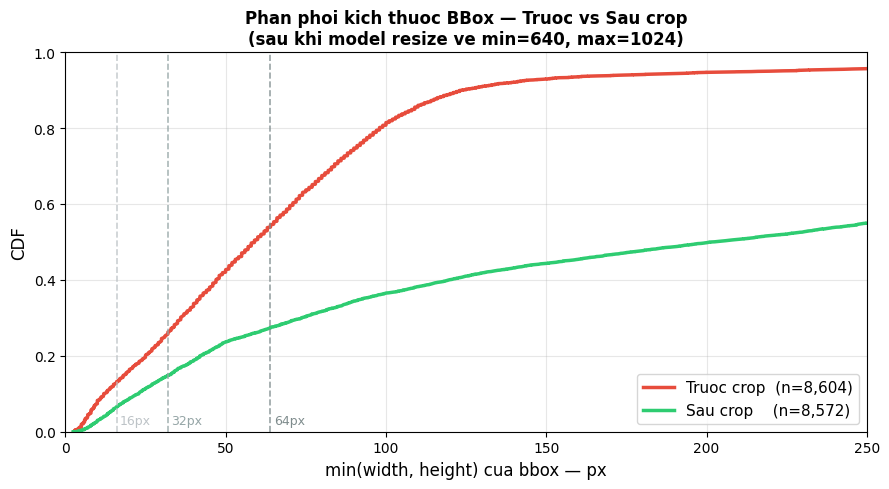

Bieu do luu tai: /workspace/_merged/crop_quality_check.png


In [9]:
def get_scale(w, h, mn=640, mx=1024):
    s = mn / min(w, h)
    if s * max(w, h) > mx:
        s = mx / max(w, h)
    return s

def analyze_sizes(ann_file: Path):
    with open(ann_file, encoding='utf-8') as f:
        data = json.load(f)
    imgs = {img['id']: img for img in data['images']}
    sizes = []
    for ann in data['annotations']:
        img = imgs[ann['image_id']]
        iw, ih = img['width'], img['height']
        bw, bh = float(ann['bbox'][2]), float(ann['bbox'][3])
        if bw <= 0 or bh <= 0: continue
        s = get_scale(iw, ih)
        sizes.append((bw * s, bh * s))
    return sizes

def pct_below(sizes, thresh):
    return 100 * sum(1 for s in sizes if min(s) < thresh) / len(sizes)

before = analyze_sizes(merged_ann_file)
after  = analyze_sizes(cropped_ann_file)

print('=' * 55)
print(f'{"Metric":<30} {"Truoc crop":>10} {"Sau crop":>10}')
print('=' * 55)
print(f'{"Tong bbox":<30} {len(before):>10} {len(after):>10}')
print(f'{"Median min-edge (px)":<30} {statistics.median([min(s) for s in before]):>10.1f} {statistics.median([min(s) for s in after]):>10.1f}')
print(f'{"Mean min-edge (px)":<30} {statistics.mean([min(s) for s in before]):>10.1f} {statistics.mean([min(s) for s in after]):>10.1f}')
print('-' * 55)
print(f'{"< 16px (sieu nho)":<30} {pct_below(before,16):>9.1f}% {pct_below(after,16):>9.1f}%')
print(f'{"< 32px (rat nho)":<30} {pct_below(before,32):>9.1f}% {pct_below(after,32):>9.1f}%')
print(f'{"< 64px (nho)":<30} {pct_below(before,64):>9.1f}% {pct_below(after,64):>9.1f}%')
pct_b = 100 - pct_below(before, 64)
pct_a = 100 - pct_below(after,  64)
print(f'{">=64px (du lon)":<30} {pct_b:>9.1f}% {pct_a:>9.1f}%  <- muc tieu')
print('=' * 55)
print(f'\nCai thien: +{pct_a - pct_b:.1f} pp cho bbox >= 64px')

# Bieu do CDF
fig, ax = plt.subplots(figsize=(9, 5))
for sizes, color, label in [
    (before, '#e74c3c', f'Truoc crop  (n={len(before):,})'),
    (after,  '#2ecc71', f'Sau crop    (n={len(after):,})'),
]:
    mins = sorted([min(s) for s in sizes])
    n    = len(mins)
    ax.plot(mins, [i/n for i in range(n)], color=color, lw=2.5, label=label)

for thr, col in [(16,'#bdc3c7'), (32,'#95a5a6'), (64,'#7f8c8d')]:
    ax.axvline(x=thr, color=col, linestyle='--', lw=1.2, alpha=0.8)
    ax.text(thr+1, 0.02, f'{thr}px', color=col, fontsize=9)

ax.set_xlim(0, 250); ax.set_ylim(0, 1)
ax.set_xlabel('min(width, height) cua bbox — px', fontsize=12)
ax.set_ylabel('CDF', fontsize=12)
ax.set_title('Phan phoi kich thuoc BBox — Truoc vs Sau crop\n(sau khi model resize ve min=640, max=1024)', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_png = MERGED_DIR / 'crop_quality_check.png'
plt.savefig(out_png, dpi=150)
plt.show()
print(f'Bieu do luu tai: {out_png}')

## Cell 7 — Chia split 80 / 10 / 10

In [10]:
random.seed(42)

def split_coco(ann_file: Path, img_src_dir: Path, out_dir: Path,
               train_ratio=0.8, valid_ratio=0.1):
    with open(ann_file, encoding='utf-8') as f:
        data = json.load(f)

    images = data['images'].copy()
    random.shuffle(images)

    n       = len(images)
    n_train = int(n * train_ratio)
    n_valid = int(n * valid_ratio)
    splits  = {
        'train': images[:n_train],
        'valid': images[n_train : n_train + n_valid],
        'test':  images[n_train + n_valid:],
    }

    ann_by_img = defaultdict(list)
    for ann in data['annotations']:
        ann_by_img[ann['image_id']].append(ann)

    cat_map = {c['id']: c['name'] for c in data['categories']}

    for split_name, split_imgs in splits.items():
        dst_img = out_dir / split_name / 'images'
        dst_img.mkdir(parents=True, exist_ok=True)

        split_ids  = {img['id'] for img in split_imgs}
        split_anns = [a for img_id in split_ids
                      for a in ann_by_img.get(img_id, [])]

        for img in tqdm(split_imgs, desc=f'Copy {split_name}', leave=False):
            src = img_src_dir / img['file_name']
            dst = dst_img     / img['file_name']
            if src.exists() and not dst.exists():
                shutil.copy(src, dst)

        split_data = {
            'images':      split_imgs,
            'annotations': split_anns,
            'categories':  data['categories'],
        }
        with open(out_dir / split_name / '_annotations.coco.json',
                  'w', encoding='utf-8') as f:
            json.dump(split_data, f, ensure_ascii=False)

        cls_dist = Counter(cat_map[a['category_id']] for a in split_anns)
        print(f'  {split_name:5s}: {len(split_imgs):5d} anh | '
              f'{len(split_anns):6d} bbox | {dict(cls_dist)}')


print('Chia split 80/10/10...')
split_coco(
    ann_file    = cropped_ann_file,
    img_src_dir = cropped_img_dir,
    out_dir     = CROPPED_DIR,
)
print(f'\nHoan thanh! Dataset luu tai: {CROPPED_DIR}')

Chia split 80/10/10...


  train:  3932 anh |   6871 bbox | {'no_helmet': 3031, 'helmet': 3840}


  valid:   491 anh |    834 bbox | {'helmet': 468, 'no_helmet': 366}


  test :   492 anh |    867 bbox | {'helmet': 529, 'no_helmet': 338}

Hoan thanh! Dataset luu tai: /workspace/dataset_coco_cropped


## Cell 8 — Kiểm tra dataset đầu ra

In [11]:
print('===== THONG KE DATASET DAU RA =====')
total_imgs = total_anns = 0
cat_map = {c['id']: c['name'] for c in FINAL_CATEGORIES}

for split in ['train', 'valid', 'test']:
    ann_path = CROPPED_DIR / split / '_annotations.coco.json'
    with open(ann_path, encoding='utf-8') as f:
        d = json.load(f)
    n_img = len(d['images'])
    n_ann = len(d['annotations'])
    total_imgs += n_img
    total_anns += n_ann
    cls_dist = Counter(cat_map[a['category_id']] for a in d['annotations'])
    print(f'  {split:5s}: {n_img:5d} anh | {n_ann:6d} annotations | {dict(cls_dist)}')

print(f'  {"TOTAL":5s}: {total_imgs:5d} anh | {total_anns:6d} annotations')
print(f'\nCau truc thu muc:')
for split in ['train', 'valid', 'test']:
    n_imgs = len(list((CROPPED_DIR / split / 'images').glob('*')))
    print(f'  {CROPPED_DIR / split} ({n_imgs} anh)')

===== THONG KE DATASET DAU RA =====
  train:  3932 anh |   6871 annotations | {'no_helmet': 3031, 'helmet': 3840}
  valid:   491 anh |    834 annotations | {'helmet': 468, 'no_helmet': 366}
  test :   492 anh |    867 annotations | {'helmet': 529, 'no_helmet': 338}
  TOTAL:  4915 anh |   8572 annotations

Cau truc thu muc:
  /workspace/dataset_coco_cropped/train (3932 anh)
  /workspace/dataset_coco_cropped/valid (491 anh)
  /workspace/dataset_coco_cropped/test (492 anh)


## Cell 9 — Hiển thị ảnh mẫu sau crop

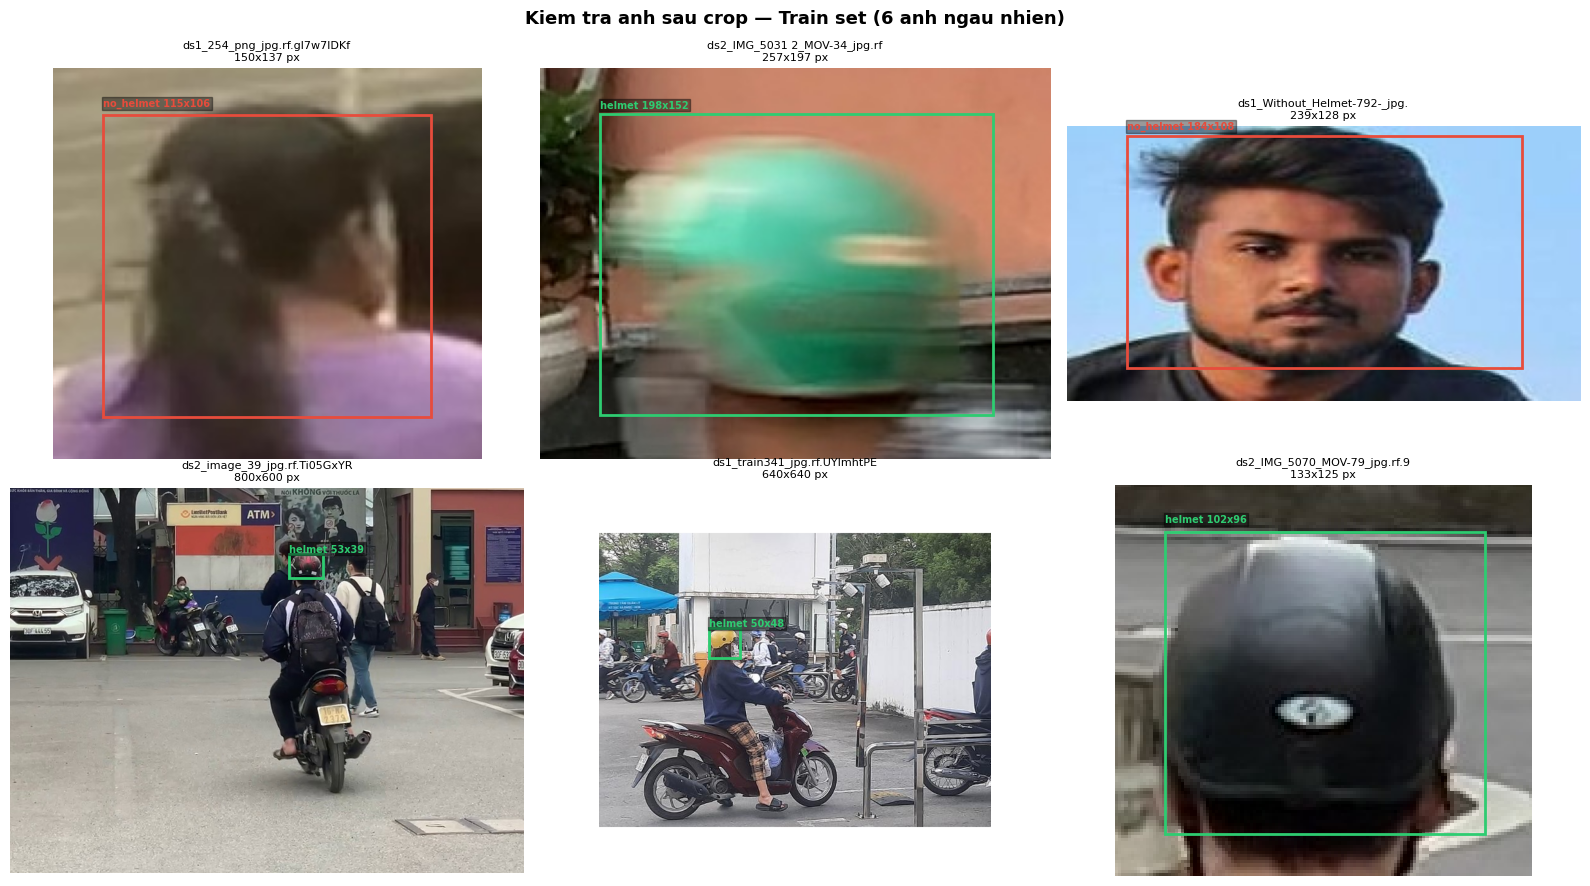

Bieu do luu tai: /workspace/dataset_coco_cropped/sample_check.png
Chu thich: xanh=helmet | do=no_helmet


In [13]:
ann_file = CROPPED_DIR / 'train' / '_annotations.coco.json'
img_dir  = CROPPED_DIR / 'train' / 'images'

with open(ann_file, encoding='utf-8') as f:
    data = json.load(f)

ann_by_img = defaultdict(list)
for ann in data['annotations']:
    ann_by_img[ann['image_id']].append(ann)

cat_map   = {c['id']: c['name'] for c in data['categories']}
cls_color = {1: '#2ecc71', 2: '#e74c3c'}  # helmet=xanh, no_helmet=do

samples = random.sample(data['images'], min(6, len(data['images'])))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Kiem tra anh sau crop — Train set (6 anh ngau nhien)',
             fontweight='bold', fontsize=13)

for ax, img_info in zip(axes.flat, samples):
    img_path = img_dir / img_info['file_name']
    img_pil  = Image.open(img_path)
    iw, ih   = img_pil.size

    ax.imshow(img_pil)
    ax.set_title(f"{img_info['file_name'][:28]}\n{iw}x{ih} px", fontsize=8)
    ax.axis('off')

    for ann in ann_by_img.get(img_info['id'], []):
        x, y, bw, bh = ann['bbox']
        name  = cat_map.get(ann['category_id'], '?')
        color = cls_color.get(ann['category_id'], 'yellow')
        rect  = patches.Rectangle((x, y), bw, bh,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, max(y-3, 0), f'{name} {bw:.0f}x{bh:.0f}',
                color=color, fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1))

plt.tight_layout()
out_png = CROPPED_DIR / 'sample_check.png'
plt.savefig(out_png, dpi=120)
plt.show()
print(f'Bieu do luu tai: {out_png}')
print('Chu thich: xanh=helmet | do=no_helmet')

## Cell 10 — Dọn dẹp file tạm (tuỳ chọn)

Xóa thư mục `_extracted` và `_merged` sau khi đã có dataset hoàn chỉnh.  
**Bỏ comment và chạy cell này nếu muốn giải phóng dung lượng.**

In [14]:
# BO COMMENT DE XOA FILE TAM

# print('Dang xoa thu muc tam...')
# shutil.rmtree(EXTRACT_DIR, ignore_errors=True)
# shutil.rmtree(MERGED_DIR,  ignore_errors=True)
# print('Xoa xong!')

print('Cell nay chua chay. Bo comment o tren neu muon don dep.')
size_extracted = sum(f.stat().st_size for f in EXTRACT_DIR.rglob('*') if f.is_file()) / 1024**3 if EXTRACT_DIR.exists() else 0
size_merged    = sum(f.stat().st_size for f in MERGED_DIR.rglob('*') if f.is_file()) / 1024**3 if MERGED_DIR.exists() else 0
size_final     = sum(f.stat().st_size for f in CROPPED_DIR.rglob('*') if f.is_file()) / 1024**3 if CROPPED_DIR.exists() else 0
print(f'  _extracted : {size_extracted:.2f} GB')
print(f'  _merged    : {size_merged:.2f} GB')
print(f'  dataset_coco_cropped (giu lai): {size_final:.2f} GB')

Cell nay chua chay. Bo comment o tren neu muon don dep.
  _extracted : 1.43 GB
  _merged    : 1.46 GB
  dataset_coco_cropped (giu lai): 0.33 GB
